# Project 2 - UCI Heart Disease Data


Uploading all functions etc.
I retrieve this from class 10 and class 16 because I work with logistic regression and decision tree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
import seaborn as sns
import cv2

from matplotlib.colors import LogNorm
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import add_dummy_feature
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from matplotlib.colors import ListedColormap
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [2]:
sns.axes_style("whitegrid")
sns.set_context("paper")
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
# this cell is intended to map the species type to an integer (1,2,3)
# for the color map

def tokenize_species(s_data):

  seto = s_data['species']=="Iris-setosa"; pseto = np.array(seto)
  vers = s_data['species']=="Iris-versicolor"; pver = np.array(vers)
  vir = s_data['species']=="Iris-virginica"; pvir = np.array(vir)

#  print(len(seto))
  s_data_coded=np.zeros(len(seto))
  for i in range(len(seto)):
    if (pseto[i]==1):
      s_data_coded[i]=1

  for i in range(len(vers)):
    if (pver[i]==1):
      s_data_coded[i]=2

  for i in range(len(vir)):
    if (pvir[i]==1):
      s_data_coded[i]=3
  return s_data_coded

In [4]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred)
    mse=metrics.mean_squared_error(y_true, y_pred)
#    mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))
    print('mean_absolute_error: ', round(mean_absolute_error,4))
#    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))


In [5]:
def model_acc(res):  # format of res should be predictions in column0, and actual in column1
    bad=0; good=0
    pred=res['pred']
    act= res['actual']

# need to keep track of good and bad predictions
#    bdata=np.zeros[len(res)]
    for i in range(len(pred)): # loop over all items
      if pred[i] >=0.5:  # if prob is >50%
        if act[i] == True: # and if flower is virginica
          good=good+1  # keep track of success
        else:
          bad=bad+1
          # keep track of failure number and location
#          bdata[i]=X_train[i] # should be the feature values from training data
      elif pred[i] <0.5:
        if act[i] == False: # correctly identifying false is also success
          good=good+1
        else:
          bad=bad+1
#          bdata[i]=X_train[i] # should be the feature values from training data

    print("Your model made ", good/len(pred)*100, "percent correct predictions\n")
# return the feature values that led to bad predictions
#    return bdata
    return

In [6]:
def model_acc_bad(res):  # format of res should be predictions in column0, and actual in column1
    bad=0; good=0
    pred=res['pred']
    act= res['actual']

# need to keep track of good and bad predictions
    bd = len(res['pred'])
    bdata=np.zeros((bd,2))
    for i in range(len(pred)): # loop over all items
      if pred[i] >=0.5:  # if prob is >50%
        if act[i] == True: # and if flower is virginica
          good=good+1  # keep track of success
        else:
          bad=bad+1
          # keep track of failure number and location
          bdata[i,0]=X_train[i][0] # should be the feature values from training data
          bdata[i,1]=X_train[i][1] # should be the feature values from training data

      elif pred[i] <0.5:
        if act[i] == False: # correctly identifying false is also success
          good=good+1
        else:
          bad=bad+1
#          bdata[i,j]=X_train[i] # should be the feature values from training data
          bdata[i,0]=X_train[i][0] # should be the feature values from training data
          bdata[i,1]=X_train[i][1] # should be the feature values from training data

    print("Your model made ", good/len(pred)*100, "percent correct predictions\n")
# return the feature values that led to bad predictions
    return bdata
#    return

In [7]:
#model_acc2(res_df,type) # 0 for setosa, 1 for versi, 2 for virg

# need condition for each type
def model_acc2(res,type):

    if (type==0):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1
    elif (type==1):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1
    elif (type==2):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1


#    m1 = res['pred']>=0.5
#    m2 = res['actual']==1
    sum12=sum(m1==m2)
    pct=sum12/len(res)*100
    print("Your model made ", pct, "percent correct predictions\n")
    return

In [8]:
def model_acc_t(res):

    m1 = res['pred']; m2 = res['actual']
    sum12 = sum(m1==m2)
    pct=sum12/len(res)*100

    print("Your model made ", pct, "percent correct predictions\n")
    return

In [9]:
def model_parm_std_err(xdata, ydata, model): # assumes xtest and ytest are not dfs
# this function was written for univariate regression,
# not yet tested for multivariate

# if you just want to check whether this algorithm works, use statsmodels

# using this with scaled data (both x and y) gives the same slope
# but a different intercept

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata


    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

    slope = modelf.coef_[0][0]
    intercept = modelf.intercept_[0]

    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)


In [10]:
def lasso_model_parm_std_err(xdata, ydata, model): # assumes xtest and ytest are not dfs
# this function was written for univariate regression for the lasso model which
# is formatted differently

# if you just want to check whether this algorithm works, use statsmodels

# using this with scaled data (both x and y) gives the same slope
# but a different intercept

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata


    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

# format for lasso
    slope = modelf.coef_[0]
    intercept = modelf.intercept_[0]


    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)

In [11]:
def mv_model_parm_std_err(xdata, ydata, model): # assumes xdata and ydata are not dfs
# this function was written for multivariate regression for the lasso model which
# is formatted differently

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata

    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

# format for lasso
    slope = []
    for i in range(len(modelf.coef_)):
      slope.append(modelf.coef_[i])

#    slope = modelf.coef_[0]
    intercept = modelf.intercept_[0]


    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    for p_ in range(p):
      std_err = var_beta_hat[p_,p_]**0.5
      if(p_==0):
        print("intercept:\t",intercept,"+/-",std_err,"\n")
        continue
#          print("slope",p_,":\t",slope[p_],"+/-",std_err,"\n")
#      else:
      print("slope",p_,":\t",slope[p_-1],"+/-",std_err,"\n")

#    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)

In [12]:
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz





#define the default font sizes to make the figures prettier
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [13]:
def class_performance(xdata,ydata,model):

# Classifiers with the score method output accuracy by default
  acc = model.score(xdata,ydata)
  predy = model.predict(xdata)
  prec, rec, fscore, supp = precision_recall_fscore_support(ydata, predy, average=None, zero_division=0)
  print("\nmodel accuracy on supplied data:\t", acc)
  # print("Precision:\t", prec.round(3),
  #       "\nRecall:\t\t", rec.round(3),
  #       "\nFscore:\t\t", fscore.round(3),
  #       "\nSupport:\t", supp)
  print("Precision:\t", prec,
        "\nRecall:\t\t", rec,
        "\nFscore:\t\t", fscore,
        "\nSupport:\t", supp)

In [14]:
#df.describe()
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred)
    mse=metrics.mean_squared_error(y_true, y_pred)
#    mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))
    print('mean_absolute_error: ', round(mean_absolute_error,4))
#    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

In [15]:
# this cell is intended to map the species type to an integer (1,2,3)
# for the color map

def tokenize_species(s_data):

  seto = s_data['species']=="Iris-setosa"; pseto = np.array(seto)
  vers = s_data['species']=="Iris-versicolor"; pver = np.array(vers)
  vir = s_data['species']=="Iris-virginica"; pvir = np.array(vir)

#  print(len(seto))
  s_data_coded=np.zeros(len(seto))
  for i in range(len(seto)):
    if (pseto[i]==1):
      s_data_coded[i]=1

  for i in range(len(vers)):
    if (pver[i]==1):
      s_data_coded[i]=2

  for i in range(len(vir)):
    if (pvir[i]==1):
      s_data_coded[i]=3
  return s_data_coded

# Upload the Dataset

In [16]:
#web_path = '' #if downloaded data to the current folder
web_path = 'http://public.gettysburg.edu/~eeleth01/' #if using data over web
#df = pd.read_csv(web_path+'SS_Report_27_8_24.csv')
df = pd.read_csv(web_path+'heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [18]:
df.columns = df.columns.str.strip().str.lower()  # Removes spaces and converts to lowercase

In [19]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [20]:
df = df.drop(["id"], axis=1)

In [21]:
df.dtypes

,0
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64
exang,object


In [22]:
df['fbs'] = df['fbs'].astype(str)
df['exang'] = df['exang'].astype(str)

In [23]:
df.dtypes

,0
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64
exang,object


In [24]:
# how much data is missing?
import numpy as np
missing = df.isnull().sum().sum()
total = np.prod(df.shape)
(missing/total)*100


np.float64(11.695652173913043)

In [25]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       920 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     920 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [27]:
# see hw6
# here we encode all of the non-numerical features
# and replace our dataframe

df_enc = df.copy()

# List of object-type columns to encode
object_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Apply LabelEncoder to each column
le = LabelEncoder()
for col in object_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

In [28]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   dataset   920 non-null    int64  
 3   cp        920 non-null    int64  
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       920 non-null    int64  
 7   restecg   920 non-null    int64  
 8   thalch    865 non-null    float64
 9   exang     920 non-null    int64  
 10  oldpeak   858 non-null    float64
 11  slope     920 non-null    int64  
 12  ca        309 non-null    float64
 13  thal      920 non-null    int64  
 14  num       920 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 107.9 KB


In [29]:
print(df_enc['cp'].unique())


[3 0 2 1]


In [30]:
# Now, I make 'num' a binary variable. 0 equals no heart disease, and 1 equals heart disease.

df_enc['num'] = np.where(df_enc['num'] == 0, 0, 1)


In [31]:
print(df_enc['num'].unique())
print(df['num'].unique())


[0 1]
[0 2 1 3 4]


# Logistic regression

In [32]:
# Compute correlation of all variables with num to get an idea of what variables are good predictors
correlation = df_enc.corr()['num'].drop('num')

# Display correlation values
correlation.sort_values(ascending=False)

,num
ca,0.455599
oldpeak,0.385528
exang,0.376623
sex,0.307284
dataset,0.295696
age,0.282700
fbs,0.235853
trestbps,0.106233
restecg,0.064268
thal,0.056516


Based on these correlations, I will incorporate the following variables into my regression:

ca (number of major vessels (0-3) colored by fluoroscopy)

exang (exercise-induced angina (True/ False))

oldpeak (ST depression induced by exercise relative to rest)

thalch (maximum heart rate achieved)

cp (chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic]))




I will also still use these to run a regression with classic risk indicators (blood metrics & age)

age

trestbps (resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))

chol (serum cholesterol in mg/dl)

fbs ((if fasting blood sugar > 120 mg/dl)


In [33]:
# Create new dataframe with only the selected variables.

dflog = df_enc[['ca', 'exang', 'oldpeak', 'thalch', 'cp', 'age', 'trestbps', 'chol', 'fbs', 'num']]
# reset the index so it starts from 0 and not from 14893.
dflog = dflog.reset_index(drop=True)
dflog

,ca,exang,oldpeak,thalch,cp,age,trestbps,chol,fbs,num
0,0.0,0,2.3,150.0,3,63,145.0,233.0,1,0
1,3.0,1,1.5,108.0,0,67,160.0,286.0,0,1
2,2.0,1,2.6,129.0,0,67,120.0,229.0,0,1
3,0.0,0,3.5,187.0,2,37,130.0,250.0,0,0
4,0.0,0,1.4,172.0,1,41,130.0,204.0,0,0
...,...,...,...,...,...,...,...,...,...,...
915,NaN,0,0.0,154.0,0,54,127.0,333.0,1,1
916,NaN,2,NaN,NaN,3,62,NaN,139.0,0,0
917,NaN,0,0.0,100.0,0,55,122.0,223.0,1,1
918,NaN,2,NaN,NaN,0,58,NaN,385.0,1,0


In [34]:
dflog.describe()

,ca,exang,oldpeak,thalch,cp,age,trestbps,chol,fbs,num
count,309.000000,920.000000,858.000000,865.000000,920.000000,920.000000,861.000000,890.000000,920.000000,920.000000
mean,0.676375,0.485870,0.878788,137.545665,0.782609,53.510870,132.132404,199.130337,0.345652,0.553261
std,0.935653,0.608085,1.091226,25.926276,0.956350,9.424685,19.066070,110.780810,0.649837,0.497426
min,0.000000,0.000000,-2.600000,60.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,120.000000,0.000000,47.000000,120.000000,175.000000,0.000000,0.000000
50%,0.000000,0.000000,0.500000,140.000000,0.000000,54.000000,130.000000,223.000000,0.000000,1.000000
75%,1.000000,1.000000,1.500000,157.000000,2.000000,60.000000,140.000000,268.000000,0.000000,1.000000
max,3.000000,2.000000,6.200000,202.000000,3.000000,77.000000,200.000000,603.000000,2.000000,1.000000


In [35]:
dflog.dropna(inplace = True)


In [36]:
dflog.describe()

,ca,exang,oldpeak,thalch,cp,age,trestbps,chol,fbs,num
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,0.678571,0.334416,1.046753,148.798701,0.948052,54.633117,131.681818,241.483766,0.175325,0.467532
std,0.936378,0.472554,1.155763,23.157267,1.035476,8.983072,17.681844,62.210343,0.421462,0.499757
min,0.000000,0.000000,-0.800000,71.000000,0.000000,29.000000,94.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,132.000000,0.000000,48.000000,120.000000,208.750000,0.000000,0.000000
50%,0.000000,0.000000,0.800000,152.000000,1.000000,56.000000,130.000000,240.000000,0.000000,0.000000
75%,1.000000,1.000000,1.600000,165.000000,2.000000,61.000000,140.000000,274.250000,0.000000,1.000000
max,3.000000,1.000000,6.200000,202.000000,3.000000,77.000000,200.000000,564.000000,2.000000,1.000000


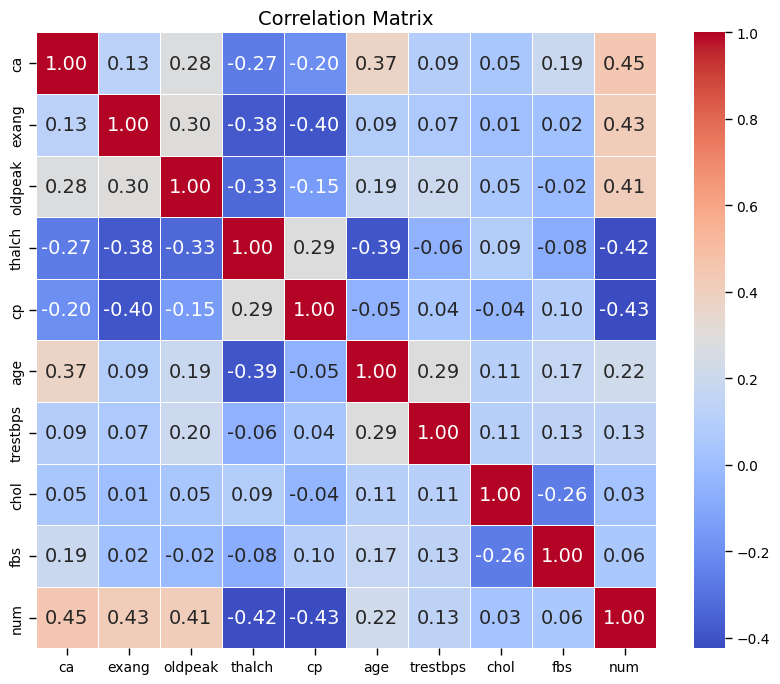

In [37]:
correlation_matrix = dflog.corr()

# Display correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

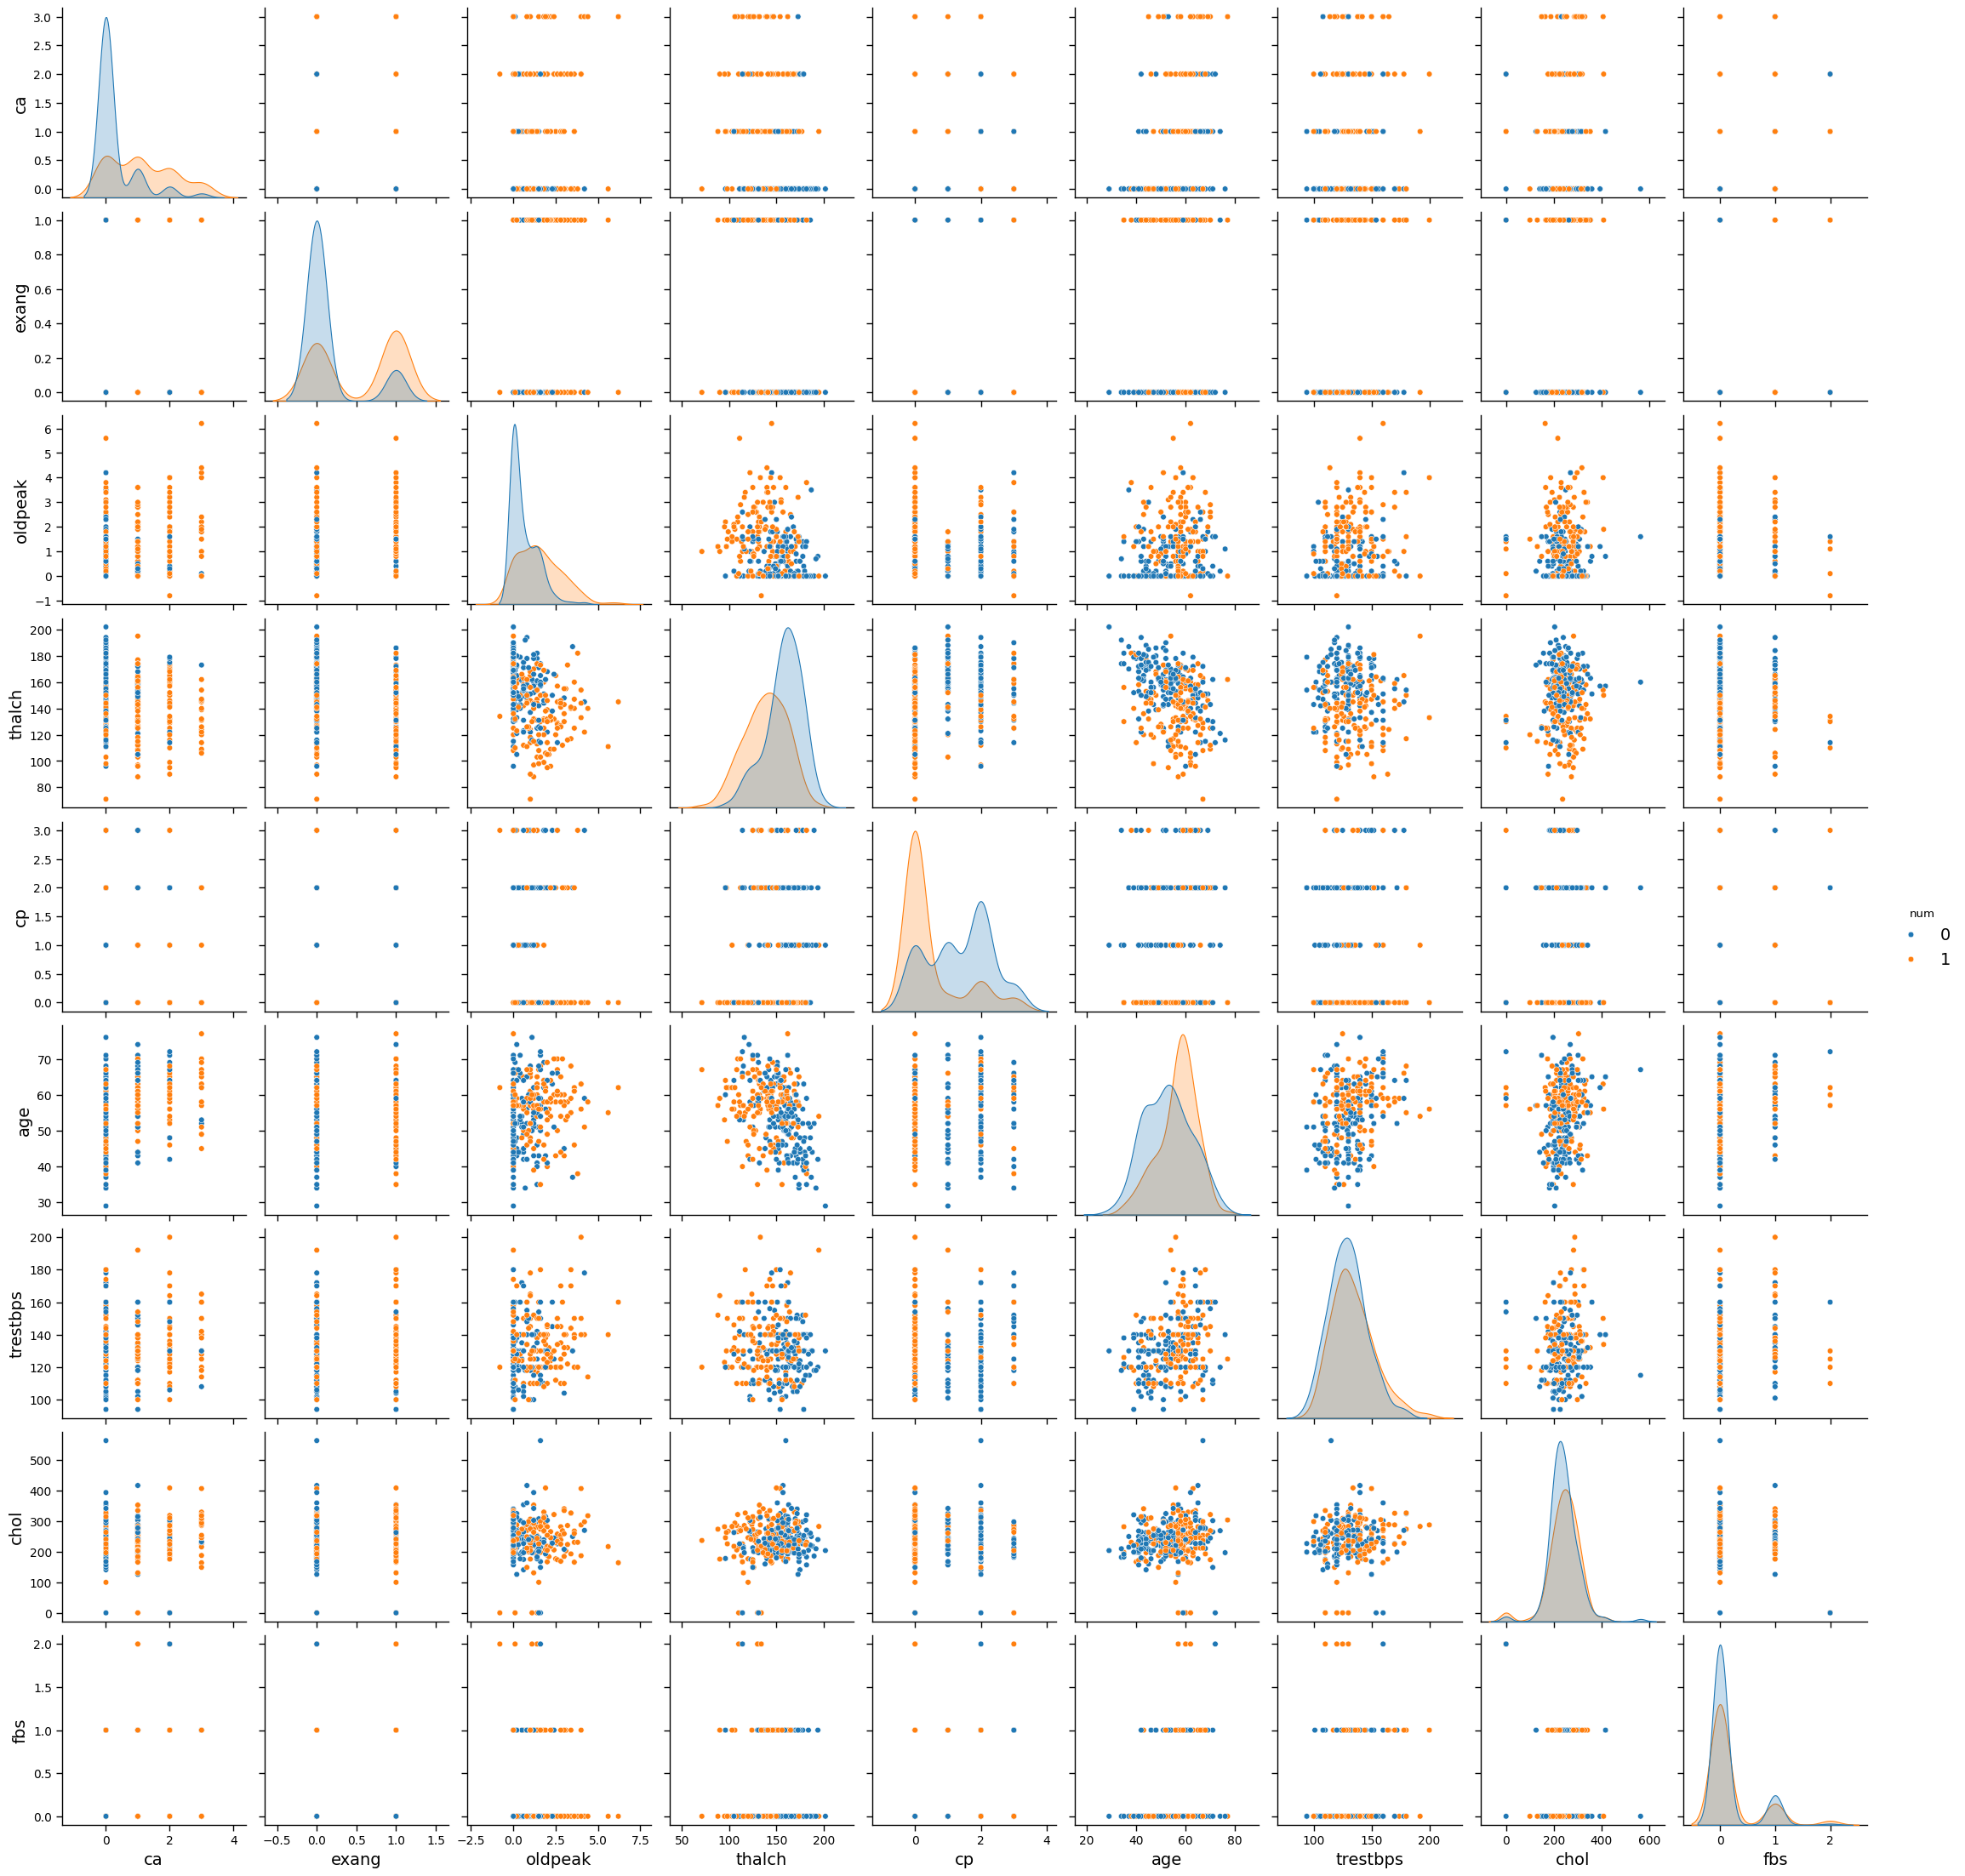

In [38]:
sns.pairplot(dflog, hue= 'num');

Now that our dataset is fully cleaned and prepared, I decided to use logistic regression since the dependent variable (num) is binary.

In [39]:
# we first start with splitting our dataset into a training set and a test set
# I chose an 80/20 train-test split to balance model learning and evaluation.

# after looking at the histograms of all variables, I decided to stratify on 'num',
# because the distribution of the training set and test set were too different.

train_set, test_set = train_test_split(dflog, test_size=0.2, stratify=dflog['num'], random_state=42)
train_set.info(), test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 284 to 135
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ca        246 non-null    float64
 1   exang     246 non-null    int64  
 2   oldpeak   246 non-null    float64
 3   thalch    246 non-null    float64
 4   cp        246 non-null    int64  
 5   age       246 non-null    int64  
 6   trestbps  246 non-null    float64
 7   chol      246 non-null    float64
 8   fbs       246 non-null    int64  
 9   num       246 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 21.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 249 to 160
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ca        62 non-null     float64
 1   exang     62 non-null     int64  
 2   oldpeak   62 non-null     float64
 3   thalch    62 non-null     float64
 4   cp        62 non-null     int64  
 5   

(None, None)

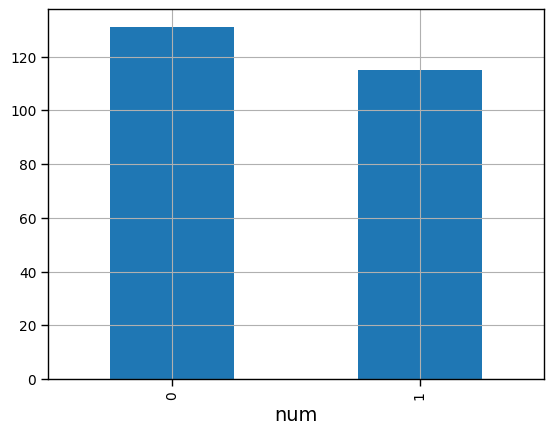

In [40]:
# Now i check if i need to stratify.

train_set['num'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

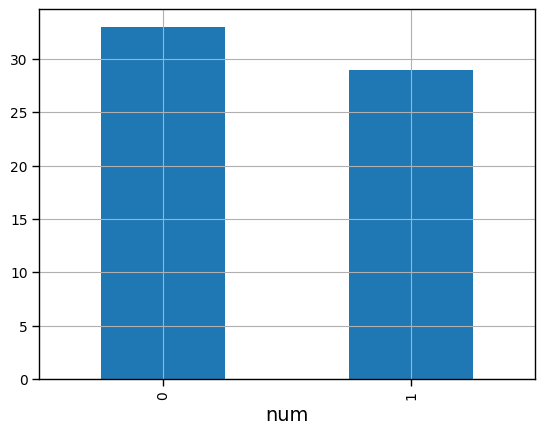

In [41]:
test_set['num'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

In [42]:
# According to class06: "For machine learning models, ideally we want all of our features to be of similar scale (that is generally 0:1 in the case of regressors"
# Therefore, I will be scaling all of them because they all have different ranges.


# Extract features as NumPy arrays
x_ca_train = np.array(train_set[["ca"]])
x_exang_train = np.array(train_set[["exang"]])
x_oldpeak_train = np.array(train_set[["oldpeak"]])
x_thalch_train = np.array(train_set[["thalch"]])
x_cp_train = np.array(train_set[["cp"]])

x_ca_test = np.array(test_set[["ca"]])
x_exang_test = np.array(test_set[["exang"]])
x_oldpeak_test = np.array(test_set[["oldpeak"]])
x_thalch_test = np.array(test_set[["thalch"]])
x_cp_test = np.array(test_set[["cp"]])

# Target variable (binary: 0 or 1)
y_train = train_set["num"].values.ravel()
y_test = test_set["num"].values.ravel()

# Create separate scalers for each feature (if needed)
scaler_ca = StandardScaler()
scaler_exang = StandardScaler()
scaler_oldpeak = StandardScaler()
scaler_thalch = StandardScaler()
scaler_cp = StandardScaler()

# Fit and transform training features
scaled_ca_train = scaler_ca.fit_transform(x_ca_train)
scaled_exang_train = scaler_exang.fit_transform(x_exang_train)
scaled_oldpeak_train = scaler_oldpeak.fit_transform(x_oldpeak_train)
scaled_thalch_train = scaler_thalch.fit_transform(x_thalch_train)
scaled_cp_train = scaler_cp.fit_transform(x_cp_train)

# Transform test features using same scalers
scaled_ca_test = scaler_ca.transform(x_ca_test)
scaled_exang_test = scaler_exang.transform(x_exang_test)
scaled_oldpeak_test = scaler_oldpeak.transform(x_oldpeak_test)
scaled_thalch_test = scaler_thalch.transform(x_thalch_test)
scaled_cp_test = scaler_cp.transform(x_cp_test)

## Model 1 - predict heart disease based on ca

In [67]:

# Initialize model
log_reg = LogisticRegression(random_state=42)

# Fit model on the scaled training data (only using 'ca')
log_reg.fit(scaled_ca_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(scaled_ca_train)
proba_test = log_reg.predict_proba(scaled_ca_test)
pred_test = log_reg.predict(scaled_ca_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_ca_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_ca_test, y_test, cv=5, scoring="accuracy").mean()

# Store results
# Threshold = 0.5 (default for binary classification, unless you specify otherwise)
accuracy_results_ca = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:,1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:,1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

accuracy_results_ca

{'Training Set Accuracy (Cross-Validated)': 0.7315918367346939,
 'Test Set Accuracy (Cross-Validated)': 0.7743589743589744,
 'Predicted Positives (Train Set, P > 0.5)': 103,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 25,
 'Actual Positives (Test Set)': 29}

## Model 2 - predict heart disease based on exang

In [44]:
# Initialize model
log_reg = LogisticRegression(random_state=42)

# Fit model using 'exang' feature
log_reg.fit(scaled_exang_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(scaled_exang_train)
proba_test = log_reg.predict_proba(scaled_exang_test)
pred_test = log_reg.predict(scaled_exang_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_exang_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_exang_test, y_test, cv=5, scoring="accuracy").mean()

# Store results with standard Python types for cleaner output
accuracy_results_exang = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:, 1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:, 1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

# Display the results
accuracy_results_exang

{'Training Set Accuracy (Cross-Validated)': 0.7275102040816327,
 'Test Set Accuracy (Cross-Validated)': 0.6435897435897436,
 'Predicted Positives (Train Set, P > 0.5)': 84,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 19,
 'Actual Positives (Test Set)': 29}

## Model 3 - predict heart disease based on oldpeak

In [45]:
# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Fit the model using 'oldpeak' as the only feature
log_reg.fit(scaled_oldpeak_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(scaled_oldpeak_train)
proba_test = log_reg.predict_proba(scaled_oldpeak_test)
pred_test = log_reg.predict(scaled_oldpeak_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_oldpeak_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_oldpeak_test, y_test, cv=5, scoring="accuracy").mean()

# Store results with standard Python types
accuracy_results_oldpeak = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:, 1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:, 1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

# Show results
accuracy_results_oldpeak

{'Training Set Accuracy (Cross-Validated)': 0.6793469387755102,
 'Test Set Accuracy (Cross-Validated)': 0.6448717948717949,
 'Predicted Positives (Train Set, P > 0.5)': 102,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 24,
 'Actual Positives (Test Set)': 29}

## Model 4 - predict heart disease based on thalch

In [46]:
# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Fit the model using 'thalch' as the only feature
log_reg.fit(scaled_thalch_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(scaled_thalch_train)
proba_test = log_reg.predict_proba(scaled_thalch_test)
pred_test = log_reg.predict(scaled_thalch_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_thalch_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_thalch_test, y_test, cv=5, scoring="accuracy").mean()

# Store results using standard Python types
accuracy_results_thalch = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:, 1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:, 1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

# Show results
accuracy_results_thalch

{'Training Set Accuracy (Cross-Validated)': 0.6995102040816328,
 'Test Set Accuracy (Cross-Validated)': 0.7294871794871794,
 'Predicted Positives (Train Set, P > 0.5)': 99,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 29,
 'Actual Positives (Test Set)': 29}

## Model 5 - predict heart disease based on cp

In [47]:
# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Fit the model using 'cp' as the only feature
log_reg.fit(scaled_cp_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(scaled_cp_train)
proba_test = log_reg.predict_proba(scaled_cp_test)
pred_test = log_reg.predict(scaled_cp_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_cp_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_cp_test, y_test, cv=5, scoring="accuracy").mean()

# Store results using standard Python types
accuracy_results_cp = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:, 1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:, 1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

# Show results
accuracy_results_cp

{'Training Set Accuracy (Cross-Validated)': 0.7598367346938776,
 'Test Set Accuracy (Cross-Validated)': 0.7410256410256411,
 'Predicted Positives (Train Set, P > 0.5)': 122,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 27,
 'Actual Positives (Test Set)': 29}

## Model 6 - Predict heart disease based on all variables

In [49]:
# Combine all scaled features into single training and test arrays
X_train_scaled = np.hstack([
    scaled_ca_train,
    scaled_exang_train,
    scaled_oldpeak_train,
    scaled_thalch_train,
    scaled_cp_train
])
X_test_scaled = np.hstack([
    scaled_ca_test,
    scaled_exang_test,
    scaled_oldpeak_test,
    scaled_thalch_test,
    scaled_cp_test
])

# Initialize and train the logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(X_train_scaled)
proba_test = log_reg.predict_proba(X_test_scaled)
pred_test = log_reg.predict(X_test_scaled)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test_scaled, y_test, cv=5, scoring="accuracy").mean()

# Store results
accuracy_results_multivariable = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:, 1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:, 1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

# Display results
accuracy_results_multivariable

{'Training Set Accuracy (Cross-Validated)': 0.8213061224489795,
 'Test Set Accuracy (Cross-Validated)': 0.7743589743589743,
 'Predicted Positives (Train Set, P > 0.5)': 103,
 'Actual Positives (Train Set)': 115,
 'Predicted Positives (Test Set, P > 0.5)': 28,
 'Actual Positives (Test Set)': 29}

##Model 7 - Predict heart disease based on symptoms (cp, exang, oldpeak)

In [50]:
# Combine the three features into one training/test set
X_train_symptoms = np.hstack([scaled_cp_train, scaled_exang_train, scaled_oldpeak_train])
X_test_symptoms = np.hstack([scaled_cp_test, scaled_exang_test, scaled_oldpeak_test])

# Train the model
log_reg_symptoms = LogisticRegression(random_state=42)
log_reg_symptoms.fit(X_train_symptoms, y_train)

# Predictions & Probabilities
proba_train_symptoms = log_reg_symptoms.predict_proba(X_train_symptoms)
proba_test_symptoms = log_reg_symptoms.predict_proba(X_test_symptoms)
pred_test_symptoms = log_reg_symptoms.predict(X_test_symptoms)

# Cross-validated accuracy
train_acc_symptoms = cross_val_score(log_reg_symptoms, X_train_symptoms, y_train, cv=5, scoring="accuracy").mean()
test_acc_symptoms = cross_val_score(log_reg_symptoms, X_test_symptoms, y_test, cv=5, scoring="accuracy").mean()

# Results
accuracy_results_symptoms = {
    "Training Set Accuracy (CV)": float(train_acc_symptoms),
    "Test Set Accuracy (CV)": float(test_acc_symptoms),
    "Predicted Positives (Train)": int(np.sum(proba_train_symptoms[:, 1] > 0.5)),
    "Actual Positives (Train)": int(np.sum(y_train)),
    "Predicted Positives (Test)": int(np.sum(proba_test_symptoms[:, 1] > 0.5)),
    "Actual Positives (Test)": int(np.sum(y_test))
}
accuracy_results_symptoms

{'Training Set Accuracy (CV)': 0.7926530612244898,
 'Test Set Accuracy (CV)': 0.708974358974359,
 'Predicted Positives (Train)': 101,
 'Actual Positives (Train)': 115,
 'Predicted Positives (Test)': 25,
 'Actual Positives (Test)': 29}

## Model 8 - Predict heart disease based classic risk indicators (blood metrics & age)

In [51]:
# Extract features as NumPy arrays
x_age_train = np.array(train_set[["age"]])
x_trestbps_train = np.array(train_set[["trestbps"]])
x_chol_train = np.array(train_set[["chol"]])
x_fbs_train = np.array(train_set[["fbs"]])

x_age_test = np.array(test_set[["age"]])
x_trestbps_test = np.array(test_set[["trestbps"]])
x_chol_test = np.array(test_set[["chol"]])
x_fbs_test = np.array(test_set[["fbs"]])

# Create separate scalers for each feature
scaler_age = StandardScaler()
scaler_trestbps = StandardScaler()
scaler_chol = StandardScaler()
scaler_fbs = StandardScaler()

# Fit and transform training features
scaled_age_train = scaler_age.fit_transform(x_age_train)
scaled_trestbps_train = scaler_trestbps.fit_transform(x_trestbps_train)
scaled_chol_train = scaler_chol.fit_transform(x_chol_train)
scaled_fbs_train = scaler_fbs.fit_transform(x_fbs_train)

# Transform test features using same scalers
scaled_age_test = scaler_age.transform(x_age_test)
scaled_trestbps_test = scaler_trestbps.transform(x_trestbps_test)
scaled_chol_test = scaler_chol.transform(x_chol_test)
scaled_fbs_test = scaler_fbs.transform(x_fbs_test)

In [52]:
# Make sure these were scaled earlier, or scale them now
X_train_risk = np.hstack([scaled_age_train, scaled_trestbps_train, scaled_chol_train, scaled_fbs_train])
X_test_risk = np.hstack([scaled_age_test, scaled_trestbps_test, scaled_chol_test, scaled_fbs_test])

# Train model
log_reg_risk = LogisticRegression(random_state=42)
log_reg_risk.fit(X_train_risk, y_train)

# Predictions & Probabilities
proba_train_risk = log_reg_risk.predict_proba(X_train_risk)
proba_test_risk = log_reg_risk.predict_proba(X_test_risk)
pred_test_risk = log_reg_risk.predict(X_test_risk)

# Cross-validated accuracy
train_acc_risk = cross_val_score(log_reg_risk, X_train_risk, y_train, cv=5, scoring="accuracy").mean()
test_acc_risk = cross_val_score(log_reg_risk, X_test_risk, y_test, cv=5, scoring="accuracy").mean()

# Results
accuracy_results_risk = {
    "Training Set Accuracy (CV)": float(train_acc_risk),
    "Test Set Accuracy (CV)": float(test_acc_risk),
    "Predicted Positives (Train)": int(np.sum(proba_train_risk[:, 1] > 0.5)),
    "Actual Positives (Train)": int(np.sum(y_train)),
    "Predicted Positives (Test)": int(np.sum(proba_test_risk[:, 1] > 0.5)),
    "Actual Positives (Test)": int(np.sum(y_test))
}
accuracy_results_risk

{'Training Set Accuracy (CV)': 0.5853877551020409,
 'Test Set Accuracy (CV)': 0.5782051282051283,
 'Predicted Positives (Train)': 100,
 'Actual Positives (Train)': 115,
 'Predicted Positives (Test)': 26,
 'Actual Positives (Test)': 29}

In [68]:
print("Univariate Model 1: Predicting heart disease based on 'ca'")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_ca['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_ca['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_ca['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_ca['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_ca['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_ca['Actual Positives (Test Set)']}")
print("-" * 50)

print("Univariate Model 2: Predicting heart disease based on 'exang'")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_exang['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_exang['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_exang['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_exang['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_exang['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_exang['Actual Positives (Test Set)']}")
print("-" * 50)

print("Univariate Model 3: Predicting heart disease based on 'oldpeak'")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_oldpeak['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_oldpeak['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_oldpeak['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_oldpeak['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_oldpeak['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_oldpeak['Actual Positives (Test Set)']}")
print("-" * 50)

print("Univariate Model 4: Predicting heart disease based on 'thalch'")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_thalch['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_thalch['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_thalch['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_thalch['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_thalch['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_thalch['Actual Positives (Test Set)']}")
print("-" * 50)

print("Univariate Model 5: Predicting heart disease based on 'cp'")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_cp['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_cp['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_cp['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_cp['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_cp['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_cp['Actual Positives (Test Set)']}")
print("-" * 50)

print("Multivariate Model 1: Predicting heart disease based on top 5 correlated variables (ca, exang, oldpeak, thalch, cp)")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_multivariable['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_multivariable['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_multivariable['Predicted Positives (Train Set, P > 0.5)']} / {accuracy_results_multivariable['Actual Positives (Train Set)']}")
print(f"Predicted Positives (Test): {accuracy_results_multivariable['Predicted Positives (Test Set, P > 0.5)']} / {accuracy_results_multivariable['Actual Positives (Test Set)']}")
print("-" * 50)

print("Multivariate Model 2: Predicting heart disease based on symptoms (cp, exang, oldpeak)")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_symptoms['Training Set Accuracy (CV)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_symptoms['Test Set Accuracy (CV)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_symptoms['Predicted Positives (Train)']} / {accuracy_results_symptoms['Actual Positives (Train)']}")
print(f"Predicted Positives (Test): {accuracy_results_symptoms['Predicted Positives (Test)']} / {accuracy_results_symptoms['Actual Positives (Test)']}")
print("-" * 50)

print("Multivariate Model 3: Predicting heart disease based on risk factors (age, trestbps, chol, fbs)")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_risk['Training Set Accuracy (CV)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_risk['Test Set Accuracy (CV)']:.3f}")
print(f"Predicted Positives (Train): {accuracy_results_risk['Predicted Positives (Train)']} / {accuracy_results_risk['Actual Positives (Train)']}")
print(f"Predicted Positives (Test): {accuracy_results_risk['Predicted Positives (Test)']} / {accuracy_results_risk['Actual Positives (Test)']}")
print("-" * 50)



Univariate Model 1: Predicting heart disease based on 'ca'
Training Set Accuracy (Cross-Validated): 0.732
Test Set Accuracy (Cross-Validated): 0.774
Predicted Positives (Train): 103 / 115
Predicted Positives (Test): 25 / 29
--------------------------------------------------
Univariate Model 2: Predicting heart disease based on 'exang'
Training Set Accuracy (Cross-Validated): 0.728
Test Set Accuracy (Cross-Validated): 0.644
Predicted Positives (Train): 84 / 115
Predicted Positives (Test): 19 / 29
--------------------------------------------------
Univariate Model 3: Predicting heart disease based on 'oldpeak'
Training Set Accuracy (Cross-Validated): 0.679
Test Set Accuracy (Cross-Validated): 0.645
Predicted Positives (Train): 102 / 115
Predicted Positives (Test): 24 / 29
--------------------------------------------------
Univariate Model 4: Predicting heart disease based on 'thalch'
Training Set Accuracy (Cross-Validated): 0.700
Test Set Accuracy (Cross-Validated): 0.729
Predicted Posit

In [53]:
comparison_df = pd.DataFrame({
    "Model": ["Symptoms (cp+exang+oldpeak)", "Risk Factors (age+bp+chol+fbs)"],
    "Train Accuracy": [accuracy_results_symptoms["Training Set Accuracy (CV)"], accuracy_results_risk["Training Set Accuracy (CV)"]],
    "Test Accuracy": [accuracy_results_symptoms["Test Set Accuracy (CV)"], accuracy_results_risk["Test Set Accuracy (CV)"]],
    "Pred Positives (Test)": [accuracy_results_symptoms["Predicted Positives (Test)"], accuracy_results_risk["Predicted Positives (Test)"]],
    "Actual Positives (Test)": [accuracy_results_symptoms["Actual Positives (Test)"], accuracy_results_risk["Actual Positives (Test)"]]
})

print(comparison_df)

                            Model  Train Accuracy  Test Accuracy  \
0     Symptoms (cp+exang+oldpeak)        0.792653       0.708974   
1  Risk Factors (age+bp+chol+fbs)        0.585388       0.578205   

   Pred Positives (Test)  Actual Positives (Test)  
0                     25                       29  
1                     26                       29  


# Decision tree

## Model 1 - Predict heart disease based on top 5 variables (correlation)

In [54]:
# Set up training data (already scaled)
X_train_tree = np.hstack([
    scaled_ca_train,
    scaled_exang_train,
    scaled_oldpeak_train,
    scaled_thalch_train,
    scaled_cp_train
])
y = y_train

# Set up test data
X_test_tree = np.hstack([
    scaled_ca_test,
    scaled_exang_test,
    scaled_oldpeak_test,
    scaled_thalch_test,
    scaled_cp_test
])

# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree.fit(X_train_tree, y)
    tree_clfs.append(best_tree)

    acc = best_tree.score(X_train_tree, y)  # Train accuracy
    acct = best_tree.score(X_test_tree, y_test)  # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

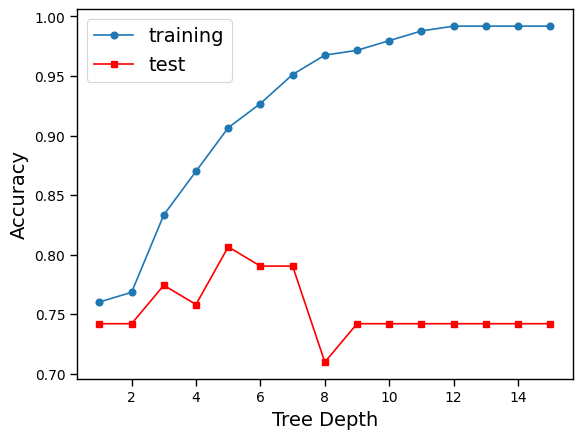

In [55]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 5.

In [56]:
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
best_tree.fit(X_train_tree, y_train)




DecisionTreeClassifier(max_depth=5, random_state=42)


model accuracy on supplied data:	 0.9065040650406504
Precision:	 [0.88028169 0.94230769] 
Recall:		 [0.95419847 0.85217391] 
Fscore:		 [0.91575092 0.89497717] 
Support:	 [131 115]


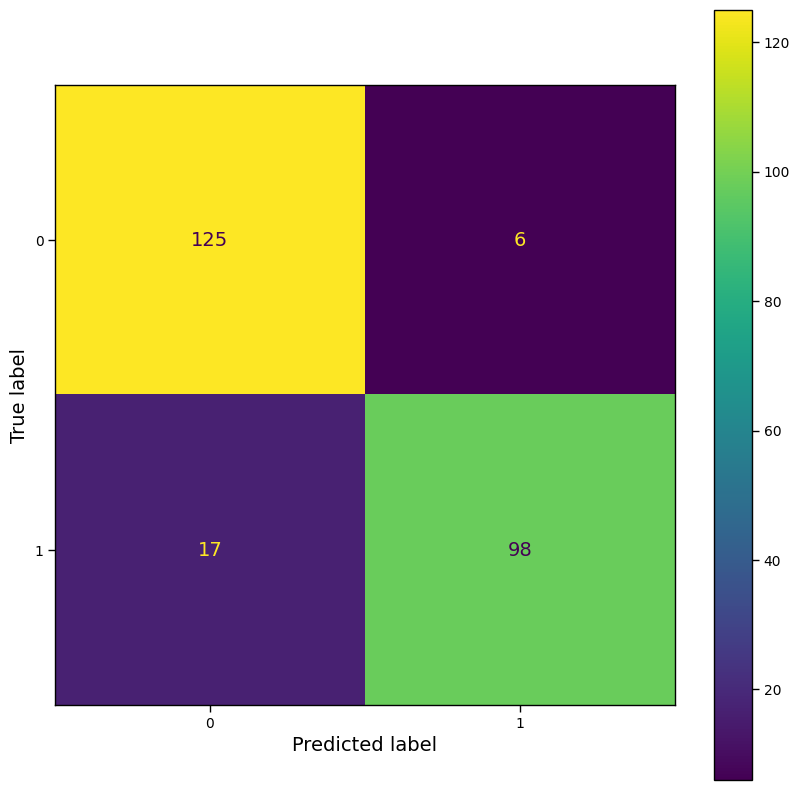

In [57]:
predy = best_tree.predict(X_train_tree)
y = y_train

class_performance(X_train_tree, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y, predy, ax=ax)

## Model 2 - Predict heart disease based on symptoms (cp, exang, oldpeak)

In [58]:
# Set up training data (symptom variables only)
X_train_tree_symptoms = np.hstack([
    scaled_cp_train,
    scaled_exang_train,
    scaled_oldpeak_train
])
X_test_tree_symptoms = np.hstack([
    scaled_cp_test,
    scaled_exang_test,
    scaled_oldpeak_test
])

y = y_train  # target stays the same

# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree_symptoms = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree_symptoms.fit(X_train_tree_symptoms, y)
    tree_clfs.append(best_tree_symptoms)

    acc = best_tree_symptoms.score(X_train_tree_symptoms, y)         # Train accuracy
    acct = best_tree_symptoms.score(X_test_tree_symptoms, y_test)    # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

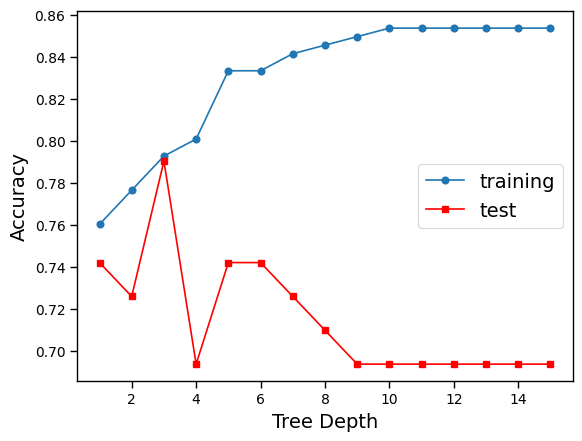

In [59]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 4.

In [60]:
best_tree_symptoms = DecisionTreeClassifier(max_depth=4, random_state=42)
best_tree_symptoms.fit(X_train_tree_symptoms, y_train)




DecisionTreeClassifier(max_depth=4, random_state=42)


model accuracy on supplied data:	 0.8008130081300813
Precision:	 [0.76973684 0.85106383] 
Recall:		 [0.89312977 0.69565217] 
Fscore:		 [0.82685512 0.76555024] 
Support:	 [131 115]


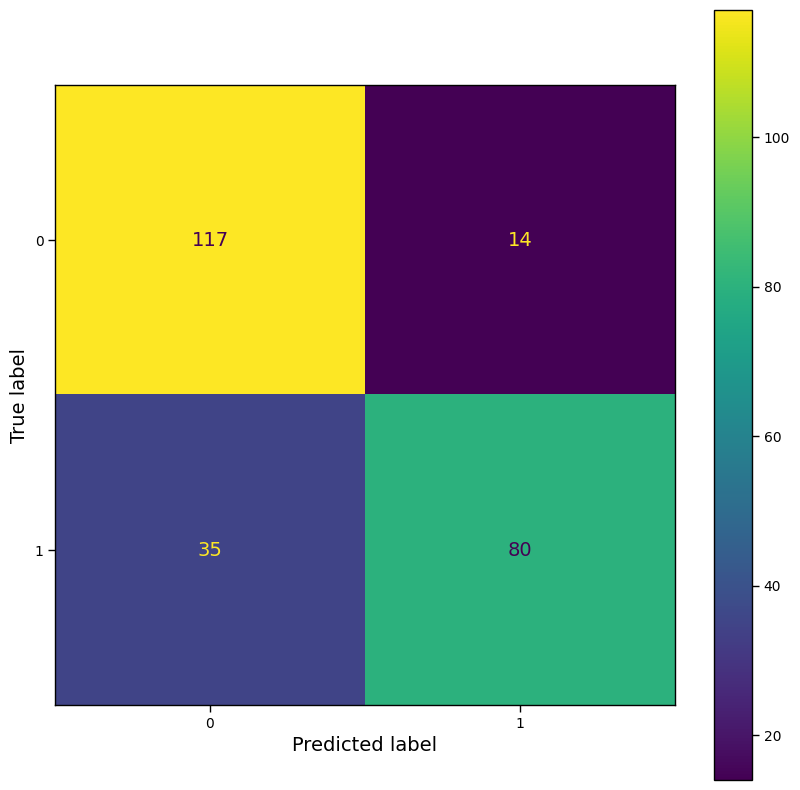

In [61]:
predy = best_tree_symptoms.predict(X_train_tree_symptoms)
y = y_train

class_performance(X_train_tree_symptoms, y_train, best_tree_symptoms)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y, predy, ax=ax)

##Model 3 - Predict heart disease based classic risk indicators (blood metrics & age)

In [62]:
# Set up training data (symptom variables only)
X_train_tree_risk = np.hstack([
    scaled_age_train,
    scaled_trestbps_train,
    scaled_chol_train,
    scaled_fbs_train
])
X_test_tree_risk = np.hstack([
    scaled_age_test,
    scaled_trestbps_test,
    scaled_chol_test,
    scaled_fbs_test
])

y = y_train  # target stays the same

# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree_risk = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree_risk.fit(X_train_tree_risk, y)
    tree_clfs.append(best_tree_risk)

    acc = best_tree_risk.score(X_train_tree_risk, y)         # Train accuracy
    acct = best_tree_risk.score(X_test_tree_risk, y_test)    # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

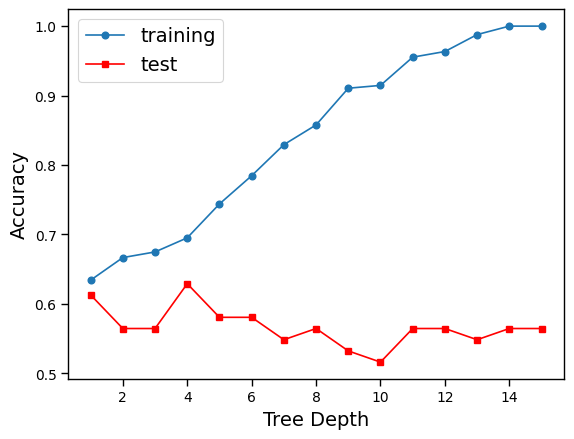

In [63]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 4.

In [64]:
best_tree_risk = DecisionTreeClassifier(max_depth=4, random_state=42)
best_tree_risk.fit(X_train_tree_risk, y_train)




DecisionTreeClassifier(max_depth=4, random_state=42)


model accuracy on supplied data:	 0.6951219512195121
Precision:	 [0.81111111 0.62820513] 
Recall:		 [0.55725191 0.85217391] 
Fscore:		 [0.66063348 0.72324723] 
Support:	 [131 115]


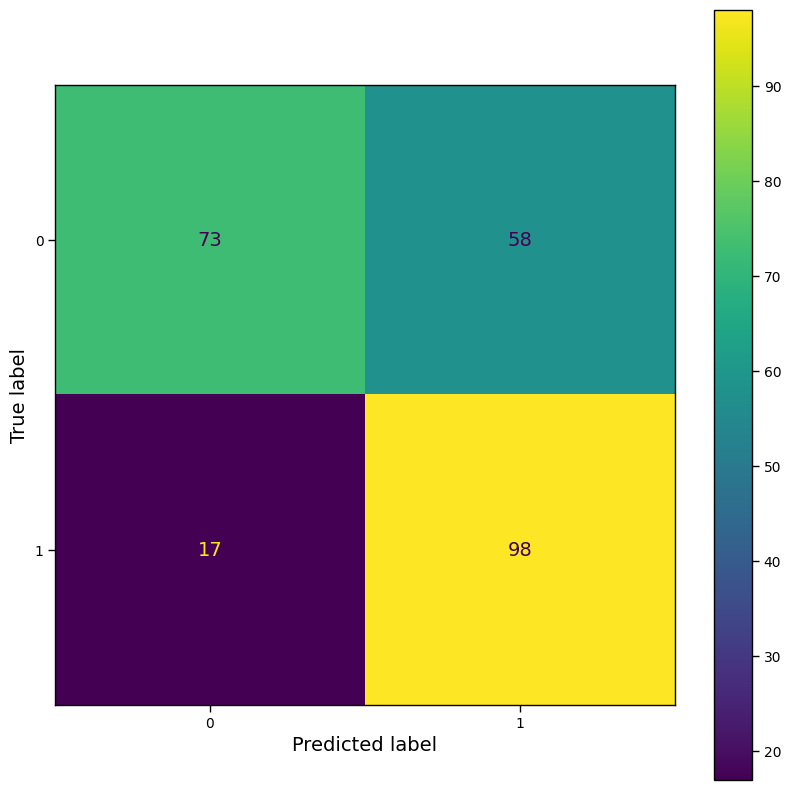

In [65]:
predy = best_tree_risk.predict(X_train_tree_risk)
y = y_train

class_performance(X_train_tree_risk, y_train, best_tree_risk)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y, predy, ax=ax)